In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

%matplotlib inline


## Question 1

Import the data set and print 10 random rows from the data set

In [14]:
colnames = ["sepal-length","sepal-width","petal-length","petal-width", "iris"]
df = pd.read_csv("iris.data",names=colnames)

df.sample(10,axis=0)

,sepal-length,sepal-width,petal-length,petal-width,iris
55,5.7,2.8,4.5,1.3,Iris-versicolor
31,5.4,3.4,1.5,0.4,Iris-setosa
53,5.5,2.3,4.0,1.3,Iris-versicolor
139,6.9,3.1,5.4,2.1,Iris-virginica
47,4.6,3.2,1.4,0.2,Iris-setosa
77,6.7,3.0,5.0,1.7,Iris-versicolor
91,6.1,3.0,4.6,1.4,Iris-versicolor
57,4.9,2.4,3.3,1.0,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica
106,4.9,2.5,4.5,1.7,Iris-virginica


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [15]:
print("Number of NULL values in each column:")
print(df.isnull().apply(sum))
print("--")
print("Number of ZERO values in each column:")
print( (df[:]==0).apply(sum))

Number of NULL values in each column:
sepal-length    0
sepal-width     0
petal-length    0
petal-width     0
iris            0
dtype: int64
--
Number of ZERO values in each column:
sepal-length    0
sepal-width     0
petal-length    0
petal-width     0
iris            0
dtype: int64


### Observation: Data seems to be sane

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

### Lets check for categorical features

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal-length    150 non-null float64
sepal-width     150 non-null float64
petal-length    150 non-null float64
petal-width     150 non-null float64
iris            150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


### 'iris' is the only column of categorical type. Lets covert it to enumerated encoding

In [17]:
df1 = df.copy()
df1.iris,label = pd.factorize(df.iris)
print(label)
df1.sample(10)

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')


,sepal-length,sepal-width,petal-length,petal-width,iris
133,6.3,2.8,5.1,1.5,2
29,4.7,3.2,1.6,0.2,0
0,5.1,3.5,1.4,0.2,0
108,6.7,2.5,5.8,1.8,2
56,6.3,3.3,4.7,1.6,1
41,4.5,2.3,1.3,0.3,0
39,5.1,3.4,1.5,0.2,0
111,6.4,2.7,5.3,1.9,2
8,4.4,2.9,1.4,0.2,0
59,5.2,2.7,3.9,1.4,1


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [18]:
df1.corr()

,sepal-length,sepal-width,petal-length,petal-width,iris
sepal-length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal-width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal-length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal-width,0.817954,-0.356544,0.962757,1.000000,0.956464
iris,0.782561,-0.419446,0.949043,0.956464,1.000000


### Observation: No feature have -0.1 to 0.1 correlation with target variable. Not dropping any features.

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [19]:
df1.var()

sepal-length    0.685694
sepal-width     0.188004
petal-length    3.113179
petal-width     0.582414
iris            0.671141
dtype: float64

### Observation: None of the independent feature variance is < 0.1. Dropping no features.

## Question 6

*Plot the scatter matrix for all the variables.*

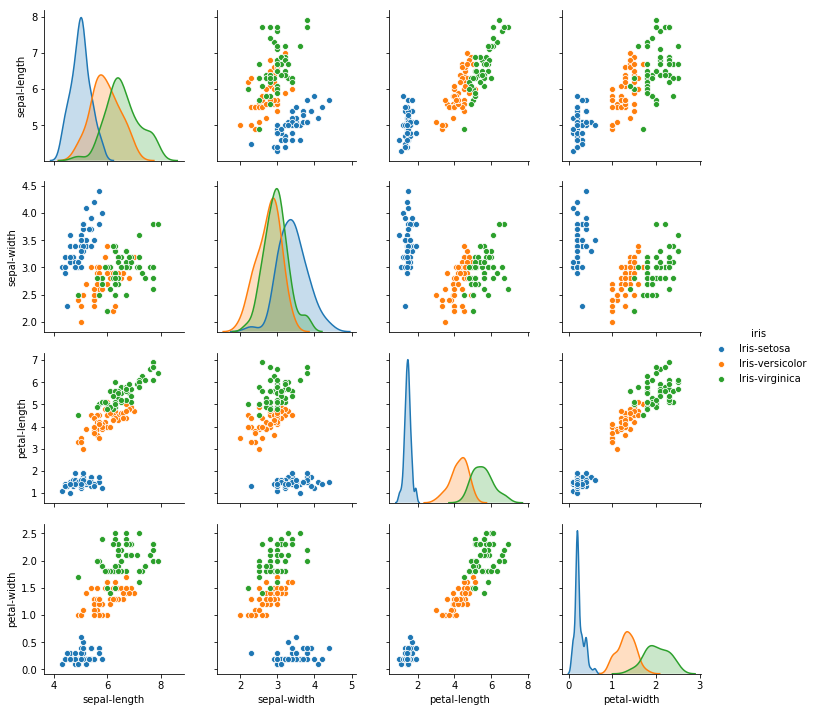

In [22]:
_= sns.pairplot(df,hue="iris")

### Observation:
- Iris-Setosa has a clear clasiffication boundries in many features
- Iris-Versicolor and Iris-Virginica has overlapping features

In [10]:
df1.groupby('iris').count()
#df1.groupby('iris').count().plot.line()

,sepal-length,sepal-width,petal-length,petal-width
iris,,,,
0,50,50,50,50
1,50,50,50,50
2,50,50,50,50


## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [11]:
X = df1.drop("iris",axis=1)
y = df1.iris
X.apply(zscore)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=5)
print("Original DataSet size:", df1.shape)
print("Train-Test DataSet size:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Original DataSet size: (150, 5)
Train-Test DataSet size: (120, 4) (30, 4) (120,) (30,)


## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [12]:
class KnnTest:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
    def accuracy(self,k):
        NNH = KNeighborsClassifier(n_neighbors=k)
        NNH.fit(self.X_train, self.y_train)
        predicted_labels = NNH.predict(self.X_test)
        testAccuracy = metrics.accuracy_score(self.y_test, predicted_labels)
        return testAccuracy


In [13]:
knnTest = KnnTest(X_train, X_test, y_train, y_test)
knnTestRes = pd.DataFrame(columns=["k", "test-accuracy"])
knnTestRes = knnTestRes.append({"k":3, "test-accuracy":knnTest.accuracy(3)}, ignore_index=True)
knnTestRes = knnTestRes.append({"k":5, "test-accuracy":knnTest.accuracy(5)}, ignore_index=True)
knnTestRes = knnTestRes.append({"k":9, "test-accuracy":knnTest.accuracy(9)}, ignore_index=True)
knnTestRes

,k,test-accuracy
0,3.0,0.933333
1,5.0,0.933333
2,9.0,0.966667


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [14]:
optimalK = 0
optimalMSE = 1
knnTestRes = pd.DataFrame(columns=["k", "mse"])
for k in range(1,20,2):
    mse = 1 - knnTest.accuracy(k)
    if mse < optimalMSE:
        optimalMSE = mse
        optimalK = k
    knnTestRes = knnTestRes.append({"k":k, "mse":mse}, ignore_index=True)
print("OptimalMSE =",optimalMSE)
print("OptimalK =", optimalK)
knnTestRes

OptimalMSE = 0.0
OptimalK = 17


,k,mse
0,1.0,0.100000
1,3.0,0.066667
2,5.0,0.066667
3,7.0,0.033333
4,9.0,0.033333
5,11.0,0.033333
6,13.0,0.033333
7,15.0,0.033333
8,17.0,0.000000
9,19.0,0.033333


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

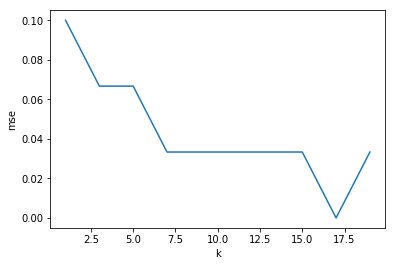

In [15]:
ax = sns.lineplot(x="k", y="mse", data=knnTestRes)

# Naive Bayes with Iris Data

In [48]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn import metrics

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [17]:
X = df1.drop("iris",axis=1)
y = df1.iris
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=5)
print("Original DataSet size:", df1.shape)
print("Train-Test DataSet size:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Original DataSet size: (150, 5)
Train-Test DataSet size: (120, 4) (30, 4) (120,) (30,)


In [18]:
#Check the dataset
print(y.head())
print(X.head())

0    0
1    0
2    0
3    0
4    0
Name: iris, dtype: int64
   sepal-length  sepal-width  petal-length  petal-width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

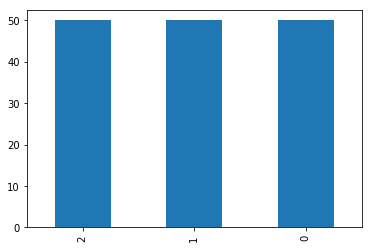

In [19]:
#df1.groupby("iris").count()
_ = df1.iris.value_counts().plot(kind='bar')

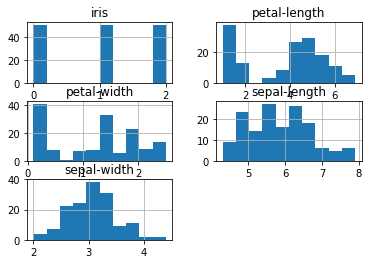

In [20]:
_ = df1.hist()

In [21]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [22]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [23]:
df1.corr()

,sepal-length,sepal-width,petal-length,petal-width,iris
sepal-length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal-width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal-length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal-width,0.817954,-0.356544,0.962757,1.000000,0.956464
iris,0.782561,-0.419446,0.949043,0.956464,1.000000


#### Observation:
- petal-length and sepal-length have high correlation with petal-width. Better to drop petal-length.
- petal-width has the next heighest correlation with sepal-length.

### Split data in Training and test set in 80:20.

In [62]:
X = X.apply(zscore)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=5)

### Question 13 
Do Feature Scaling 

In [64]:
# Use StandardScaler or similar methods

In [65]:
#Question?:
#Will scaling influenct NaiveBayes algorithm ??
#Also please note I did zscore (StandardScaler) scaling before train_test_split in this exercise.
print(X_train.head(), X_test.head())

    sepal-length  sepal-width  petal-length  petal-width
39     -0.900681     0.800654     -1.284407    -1.312977
53     -0.416010    -1.744778      0.137236     0.133226
79     -0.173674    -1.050569     -0.147093    -0.261193
10     -0.537178     1.494863     -1.284407    -1.312977
50      1.401508     0.337848      0.535296     0.264699      sepal-length  sepal-width  petal-length  petal-width
82      -0.052506    -0.819166      0.080370     0.001753
134      0.310998    -1.050569      1.047087     0.264699
114     -0.052506    -0.587764      0.762759     1.579429
42      -1.748856     0.337848     -1.398138    -1.312977
109      1.643844     1.263460      1.331416     1.710902


### Question 14 
Train and Fit NaiveBayes Model

In [66]:
#Fit the model
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [78]:
#Predict
y_predict = model.predict(X_test)
print(y_predict)

[1 1 2 0 2 1 0 2 0 1 1 1 2 2 0 0 2 2 0 0 1 2 0 1 1 2 1 1 1 2]


### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [90]:
# show Confusion Matrixcm = metrics.confusion_matrix(y_true=y_test, y_pred=y_predict, labels=[0,1,2])
print(pd.DataFrame(cm, index=['T:'+label[0], 'T:'+label[1], "T:"+label[2]], columns=['P:'+label[0], 'P:'+label[1], 'P:'+label[2]]))

                   P:Iris-setosa  P:Iris-versicolor  P:Iris-virginica
T:Iris-setosa                  8                  0                 0
T:Iris-versicolor              0                 10                 1
T:Iris-virginica               0                  2                 9


In [91]:
# show accuracy
print("Accuracy:",metrics.accuracy_score(y_true=y_test,y_pred=y_predict))

Accuracy: 0.9


In [95]:
#Show precision and Recall metrics
print(metrics.classification_report(y_true=y_test, y_pred=y_predict, target_names=label))

Precision: [1.         0.83333333 0.9       ]
Recall: [1.         0.90909091 0.81818182]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.83      0.91      0.87        11
 Iris-virginica       0.90      0.82      0.86        11

      micro avg       0.90      0.90      0.90        30
      macro avg       0.91      0.91      0.91        30
   weighted avg       0.90      0.90      0.90        30



### Observation: 
- Seems like algorithm gets bit confused between Iris-virginica and Iris-versicolor
- More Type I (False Positive) errors and Type II (False Negative) are with Iris-versicolor
- Algorithm is efficient is classifying Iris-setosa 

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [31]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [32]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [33]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [34]:
# use from sklearn.svm import SVC

In [35]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [36]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [37]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [38]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

NameError: name 'SVC' is not defined

In [ ]:
gs.fit(X_train_scaled, y_train) 

In [ ]:
gs.best_estimator_

In [ ]:
gs.best_score_ 